In [4]:
# ============================================================
# Cardiovascular Disease Prediction
# Dataset: https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset
# Download cardio_train.csv and upload when prompted
# ============================================================
!pip install pandas numpy matplotlib seaborn scikit-learn -q
print("All libraries ready.")

All libraries ready.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, f1_score,
                             precision_score, recall_score)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid", rc={"figure.figsize": (10, 6)})
print("All imports successful.")

All imports successful.


In [6]:
# Load dataset
# Download from Kaggle: https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset
try:
    from google.colab import files
    print("Upload cardio_train.csv when prompted...")
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
    df = pd.read_csv(file_name, sep=';')
except:
    df = pd.read_csv('cardio_train.csv', sep=';')

df.drop('id', axis=1, inplace=True, errors='ignore')
print(f"Dataset loaded. Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Upload cardio_train.csv when prompted...


Saving cardio_train.csv to cardio_train (1).csv
Dataset loaded. Shape: (70000, 12)
Columns: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [7]:
# Preprocessing
# 1. Convert age from days to years
df['age'] = (df['age'] / 365).round().astype(int)

# 2. Fill missing values with median
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# 3. BP outlier removal
df = df[
    (df['ap_hi'] > 0) & (df['ap_lo'] > 0) &
    (df['ap_hi'] < 300) & (df['ap_lo'] < 200)
]

# 4. BMI feature engineering
df['bmi'] = df['weight'] / (df['height'] / 100) ** 2

print(f"After preprocessing: {df.shape}")
print(f"\nClass distribution (cardio):")
print(df['cardio'].value_counts())
df.describe()

After preprocessing: (68985, 13)

Class distribution (cardio):
cardio
0    34844
1    34141
Name: count, dtype: int64


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
count,68985.000000,68985.000000,68985.000000,68985.000000,68985.000000,68985.000000,68985.000000,68985.000000,68985.000000,68985.000000,68985.000000,68985.000000,68985.000000
mean,53.324926,1.348670,164.359672,74.118961,126.325027,81.350482,1.364384,1.225875,0.087860,0.053591,0.803276,0.494905,27.524761
std,6.767669,0.476553,8.204273,14.328938,17.698621,9.805666,0.678691,0.571822,0.283093,0.225211,0.397525,0.499978,6.081130
min,30.000000,1.000000,55.000000,11.000000,7.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.471784
25%,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,23.875115
50%,54.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,26.346494
75%,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,30.119376
max,65.000000,2.000000,250.000000,200.000000,240.000000,190.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,298.666667


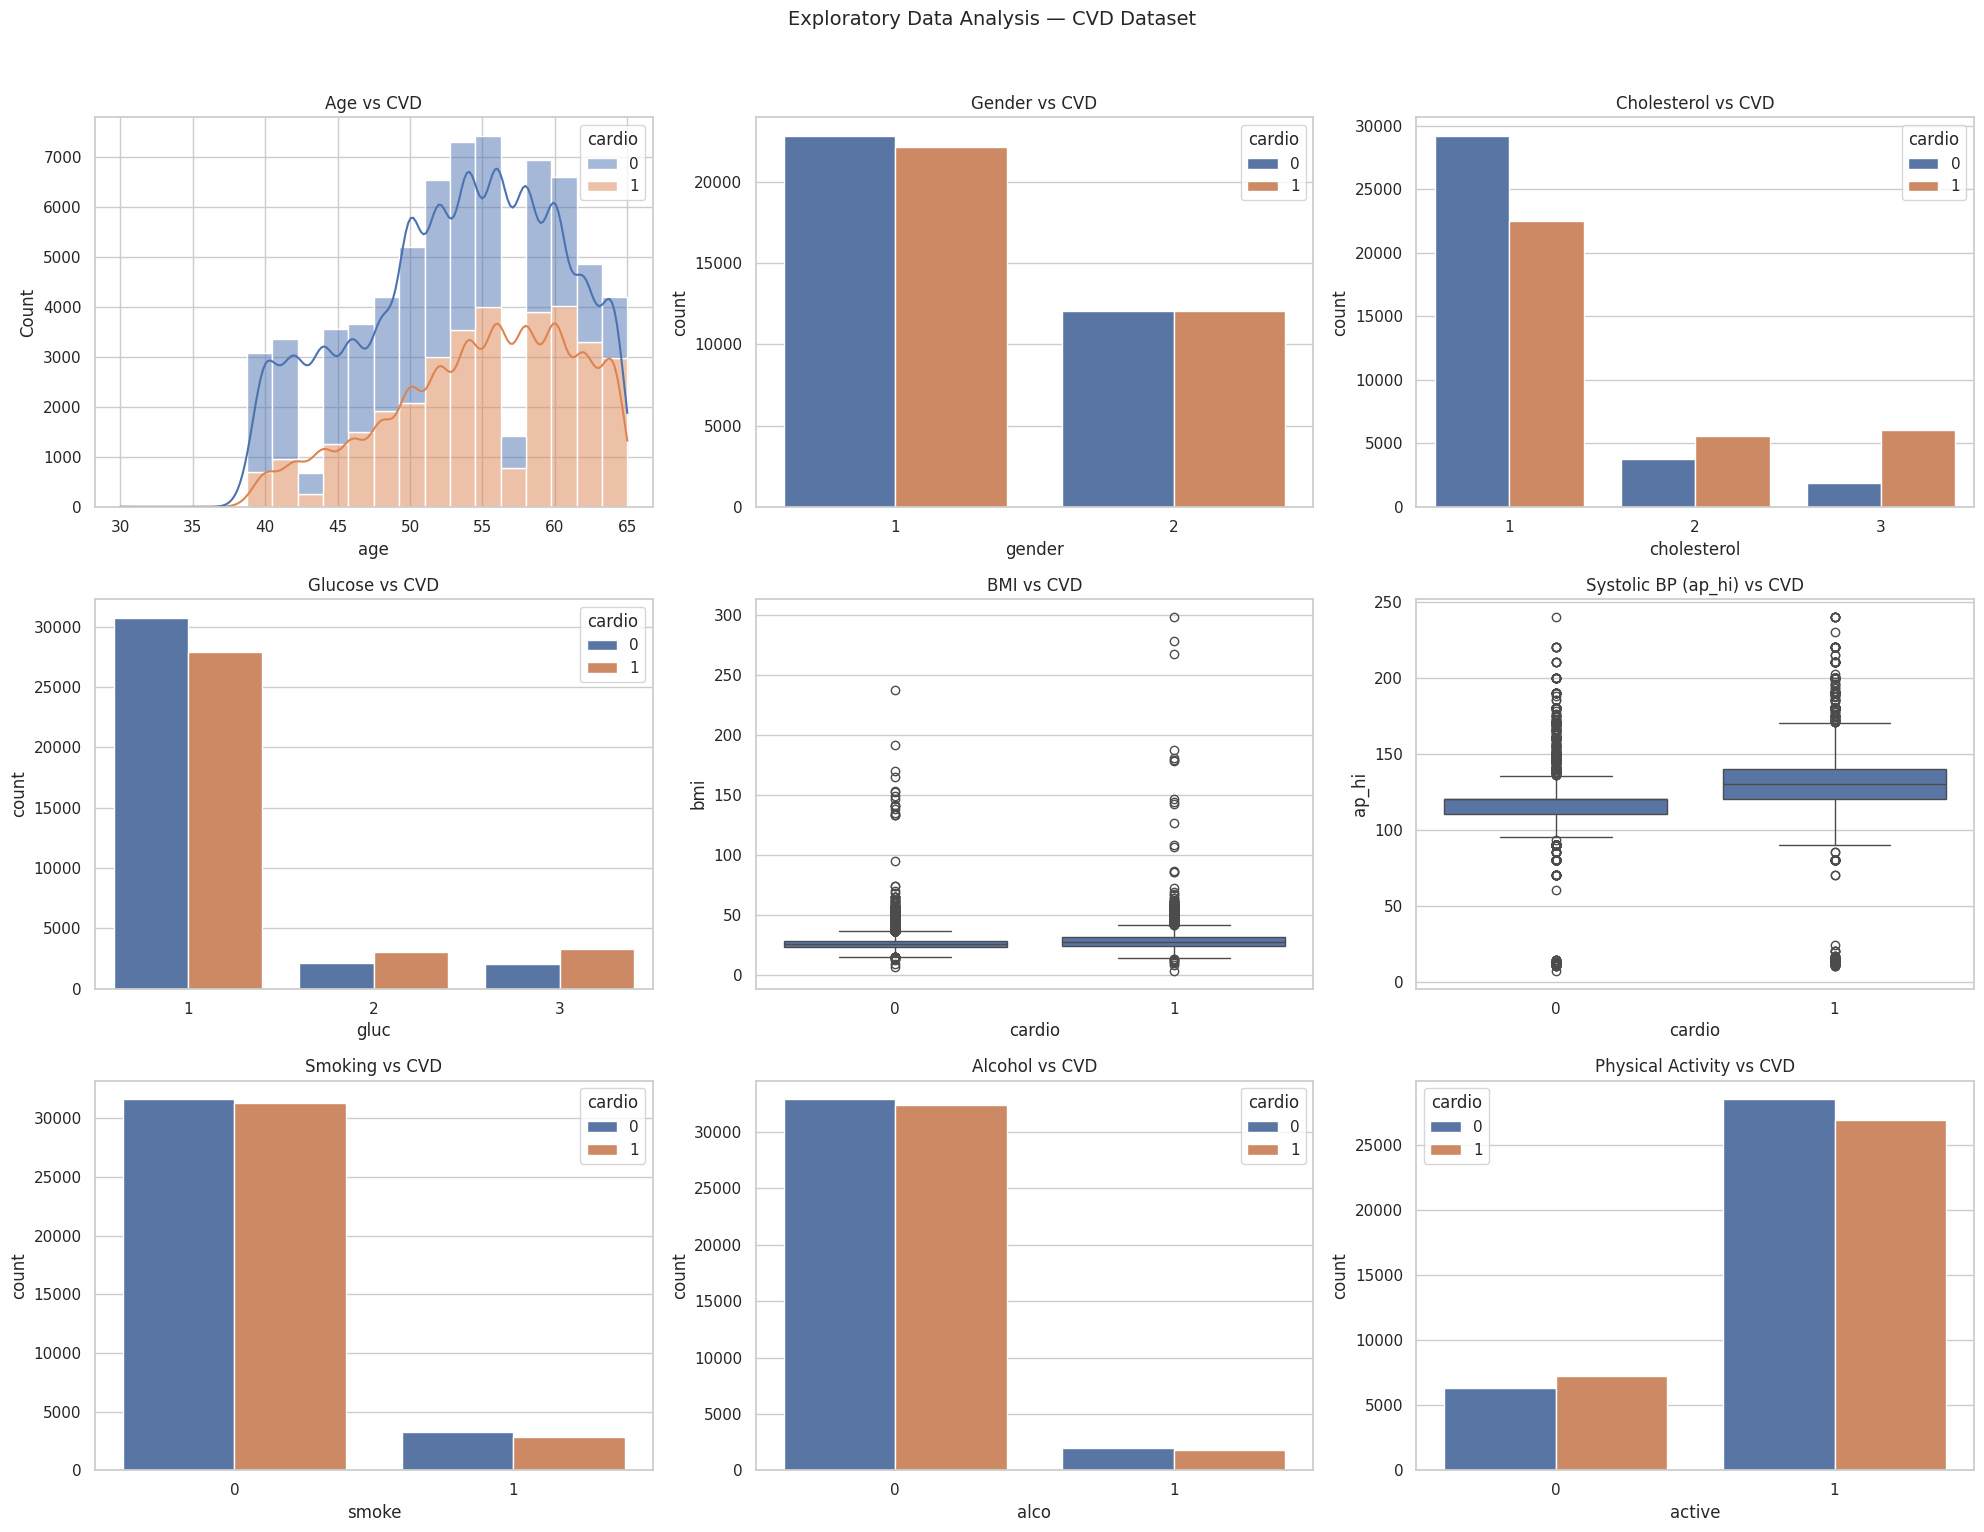

In [8]:
# Exploratory Data Analysis
fig, axes = plt.subplots(3, 3, figsize=(20, 15))

sns.histplot(data=df, x='age', hue='cardio', multiple='stack',
             kde=True, bins=20, ax=axes[0,0])
axes[0,0].set_title('Age vs CVD')

sns.countplot(x='gender', hue='cardio', data=df, ax=axes[0,1])
axes[0,1].set_title('Gender vs CVD')

sns.countplot(x='cholesterol', hue='cardio', data=df, ax=axes[0,2])
axes[0,2].set_title('Cholesterol vs CVD')

sns.countplot(x='gluc', hue='cardio', data=df, ax=axes[1,0])
axes[1,0].set_title('Glucose vs CVD')

sns.boxplot(x='cardio', y='bmi', data=df, ax=axes[1,1])
axes[1,1].set_title('BMI vs CVD')

sns.boxplot(x='cardio', y='ap_hi', data=df, ax=axes[1,2])
axes[1,2].set_title('Systolic BP (ap_hi) vs CVD')

sns.countplot(x='smoke', hue='cardio', data=df, ax=axes[2,0])
axes[2,0].set_title('Smoking vs CVD')

sns.countplot(x='alco', hue='cardio', data=df, ax=axes[2,1])
axes[2,1].set_title('Alcohol vs CVD')

sns.countplot(x='active', hue='cardio', data=df, ax=axes[2,2])
axes[2,2].set_title('Physical Activity vs CVD')

plt.suptitle('Exploratory Data Analysis — CVD Dataset', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

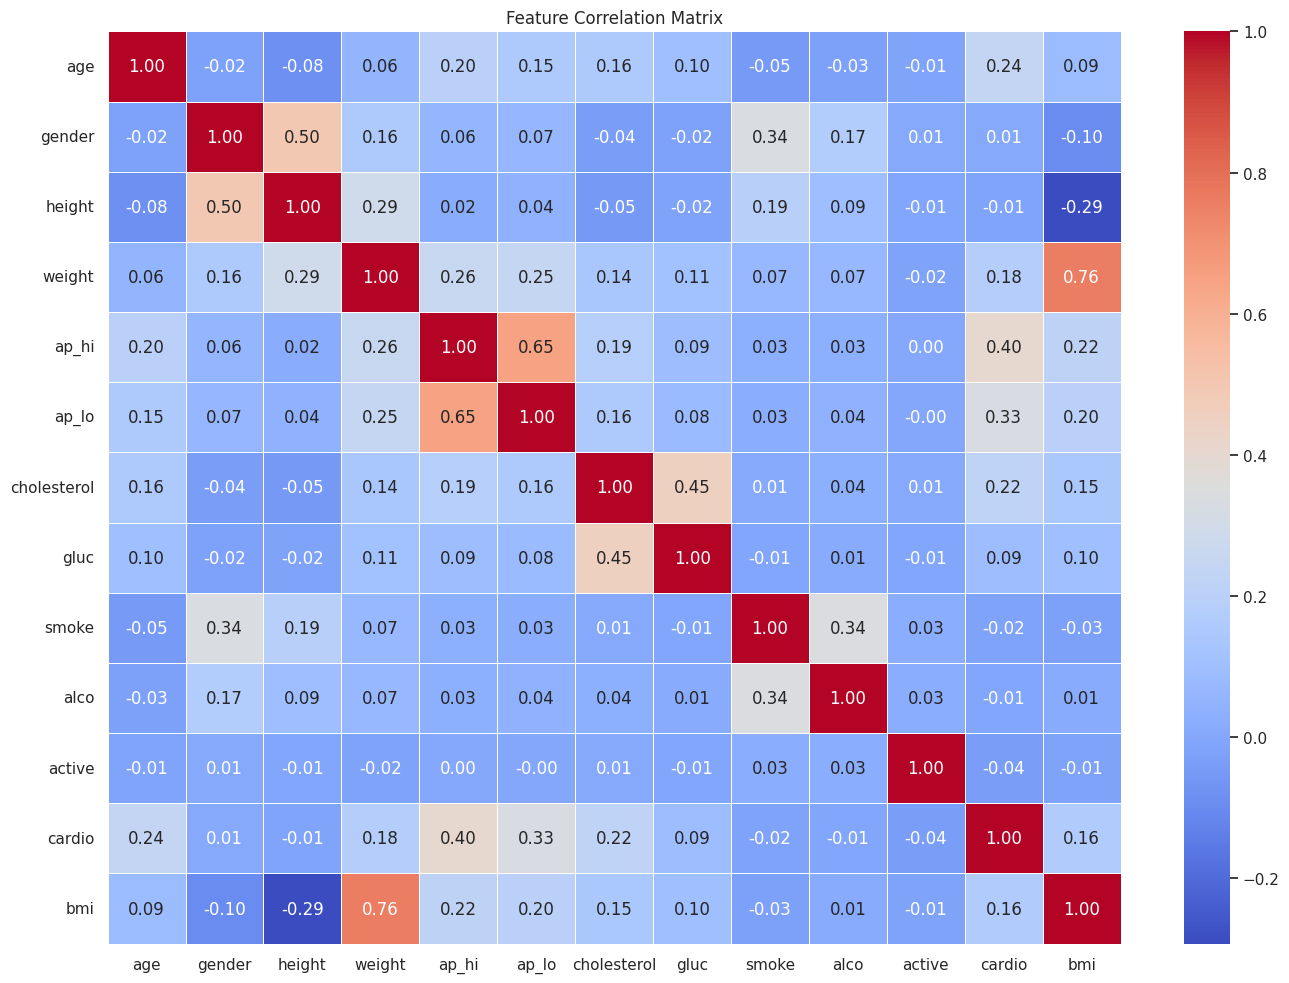


Top correlations with CVD target:
cardio         1.000000
ap_hi          0.401471
ap_lo          0.330705
age            0.239280
cholesterol    0.221441
weight         0.179978
bmi            0.163600
gluc           0.089715
Name: cardio, dtype: float64


In [9]:
# Correlation Matrix
plt.figure(figsize=(14, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("\nTop correlations with CVD target:")
print(corr['cardio'].abs().sort_values(ascending=False).head(8))

In [10]:
# Train/Test Split and Scaling
X = df.drop('cardio', axis=1)
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Features: {list(X.columns)}")

Train: 55188 samples | Test: 13797 samples
Features: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']


=== Baseline Model Results ===

Logistic Regression:
  Accuracy=0.7235  F1=0.7054  Precision=0.7461  Recall=0.6689


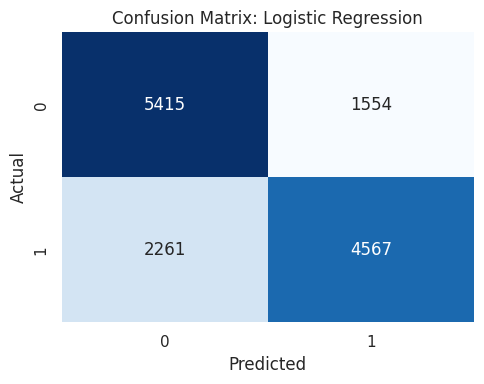


Decision Tree:
  Accuracy=0.6289  F1=0.6175  Precision=0.6302  Recall=0.6053


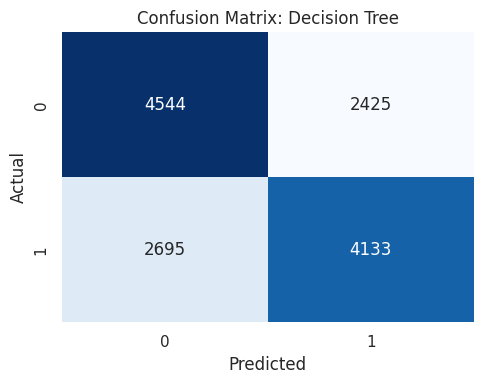


Random Forest:
  Accuracy=0.7010  F1=0.6951  Precision=0.7017  Recall=0.6885


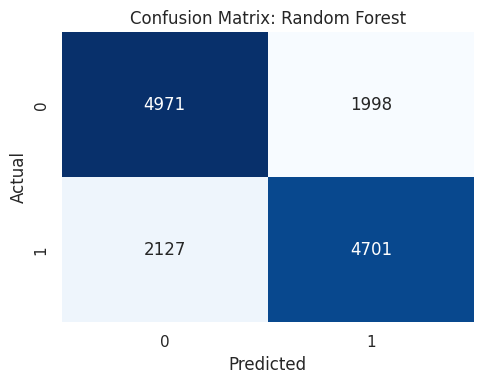


K-Nearest Neighbor:
  Accuracy=0.6885  F1=0.6817  Precision=0.6895  Recall=0.6740


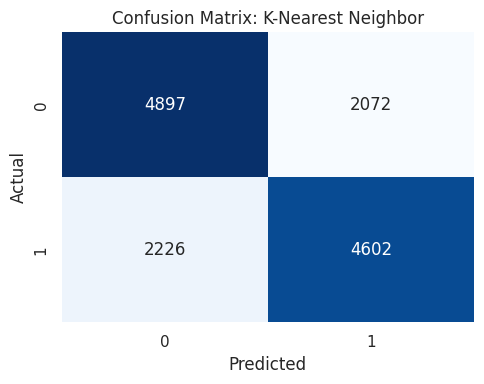


Support Vector Machine:
  Accuracy=0.7302  F1=0.7102  Precision=0.7578  Recall=0.6683


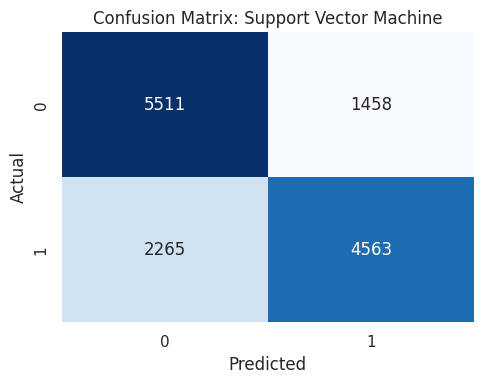

In [11]:
# Baseline Benchmarking — 5 Classifiers
models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':          DecisionTreeClassifier(random_state=42),
    'Random Forest':          RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbor':     KNeighborsClassifier(),
    'Support Vector Machine': SVC(random_state=42)
}

results = {}
print("=== Baseline Model Results ===\n")

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    results[name] = {'Accuracy': acc, 'F1': f1, 'Precision': prec, 'Recall': rec}

    print(f"{name}:")
    print(f"  Accuracy={acc:.4f}  F1={f1:.4f}  Precision={prec:.4f}  Recall={rec:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()
    print()

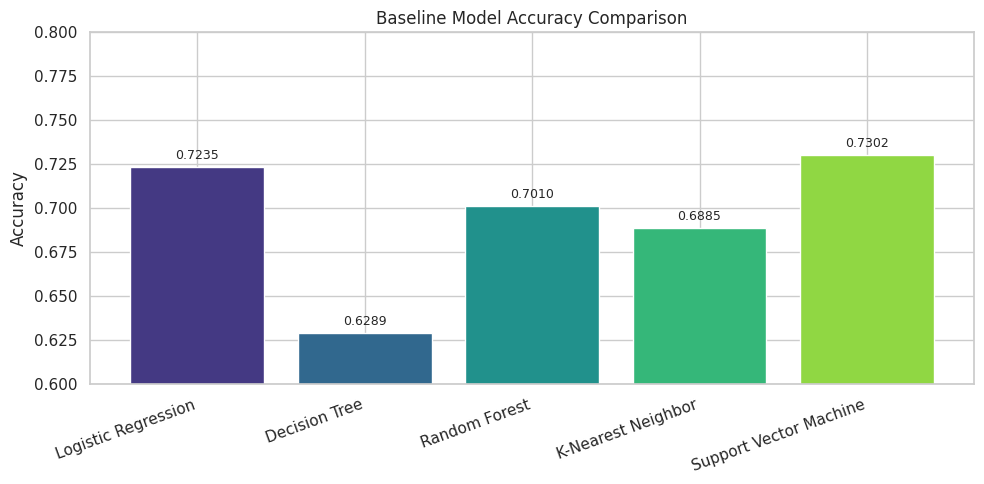

Best baseline model: Support Vector Machine with Accuracy: 0.7302


In [12]:
# Accuracy Comparison Bar Chart
model_names = list(results.keys())
accuracies  = [results[n]['Accuracy'] for n in model_names]

plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, accuracies, color=sns.color_palette('viridis', len(model_names)))
plt.xticks(rotation=20, ha='right')
plt.ylabel('Accuracy')
plt.ylim(0.6, 0.8)
plt.title('Baseline Model Accuracy Comparison')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

best_baseline = max(results, key=lambda n: results[n]['Accuracy'])
print(f"Best baseline model: {best_baseline} with Accuracy: {results[best_baseline]['Accuracy']:.4f}")

In [13]:
# Grid-Search Hyperparameter Tuning
print("=== Grid-Search Tuning ===\n")

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grids = {
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [10, 20],
            'min_samples_split': [2, 5]
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'solver': ['lbfgs']
        }
    }
}

tuned_models  = {}
tuned_results = {}

for name, cfg in param_grids.items():
    print(f"Tuning {name}...")
    gs = GridSearchCV(cfg['model'], cfg['params'], cv=cv,
                      scoring='accuracy', n_jobs=-1, verbose=0)
    gs.fit(X_train_scaled, y_train)
    best = gs.best_estimator_
    y_pred = best.predict(X_test_scaled)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)

    tuned_models[name]  = best
    tuned_results[name] = {'Accuracy': acc, 'F1': f1, 'Precision': prec, 'Recall': rec}

    print(f"  Best params : {gs.best_params_}")
    print(f"  Accuracy={acc:.4f}  F1={f1:.4f}  Precision={prec:.4f}  Recall={rec:.4f}\n")

# Add remaining models at baseline
tuned_results['Support Vector Machine'] = results['Support Vector Machine']
tuned_results['Decision Tree'] = results['Decision Tree']
tuned_results['K-Nearest Neighbor'] = results['K-Nearest Neighbor']
print("SVM, DT, KNN kept at baseline (tuning skipped for speed)")

=== Grid-Search Tuning ===

Tuning Random Forest...
  Best params : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
  Accuracy=0.7281  F1=0.7099  Precision=0.7519  Recall=0.6724

Tuning Logistic Regression...
  Best params : {'C': 0.1, 'solver': 'lbfgs'}
  Accuracy=0.7235  F1=0.7054  Precision=0.7460  Recall=0.6690

SVM, DT, KNN kept at baseline (tuning skipped for speed)


/tmp/ipykernel_6109/310893209.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


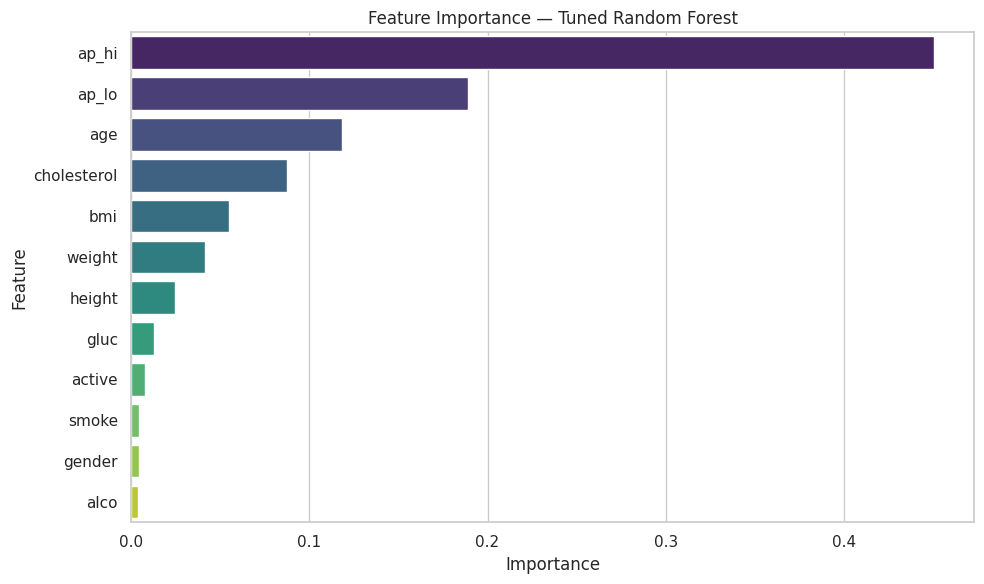


Top CVD Risk Predictors:
    Feature  Importance
      ap_hi    0.450457
      ap_lo    0.189116
        age    0.118399
cholesterol    0.087458
        bmi    0.054740


In [14]:
# Feature Importance — Tuned Random Forest
rf_model = tuned_models['Random Forest']
importances  = rf_model.feature_importances_
feature_names = list(X.columns)

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance — Tuned Random Forest')
plt.tight_layout(); plt.show()

print("\nTop CVD Risk Predictors:")
print(feat_imp_df.head(5).to_string(index=False))

=== Final Model Comparison: Baseline vs Grid-Search Tuned ===

                 Model Baseline Acc Tuned Acc Tuned F1 Tuned Precision Tuned Recall
   Logistic Regression       0.7235    0.7235   0.7054          0.7460       0.6690
         Decision Tree       0.6289    0.6289   0.6175          0.6302       0.6053
         Random Forest       0.7010    0.7281   0.7099          0.7519       0.6724
    K-Nearest Neighbor       0.6885    0.6885   0.6817          0.6895       0.6740
Support Vector Machine       0.7302    0.7302   0.7102          0.7578       0.6683


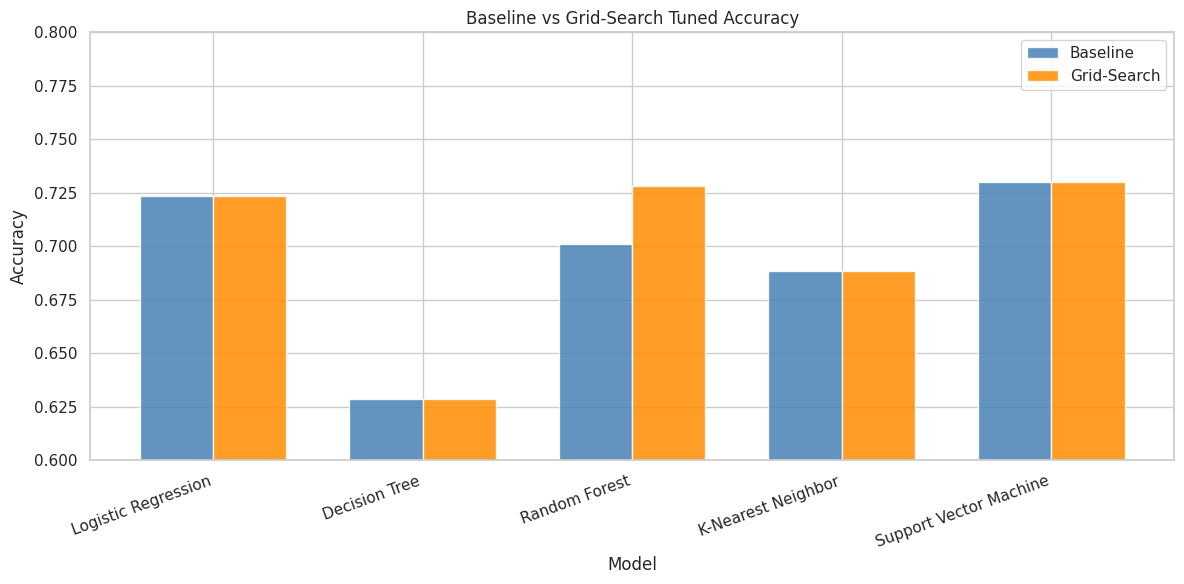


Best model after Grid-Search tuning: Support Vector Machine
Best accuracy: 0.7302


In [15]:
# Final Comparison: Baseline vs Tuned
print("=== Final Model Comparison: Baseline vs Grid-Search Tuned ===\n")

rows = []
for name in models.keys():
    base  = results[name]
    tuned = tuned_results.get(name, base)
    rows.append({
        'Model':          name,
        'Baseline Acc':   f"{base['Accuracy']:.4f}",
        'Tuned Acc':      f"{tuned['Accuracy']:.4f}",
        'Tuned F1':       f"{tuned['F1']:.4f}",
        'Tuned Precision':f"{tuned['Precision']:.4f}",
        'Tuned Recall':   f"{tuned['Recall']:.4f}"
    })

comp_df = pd.DataFrame(rows)
print(comp_df.to_string(index=False))

# Side-by-side bar chart
all_names   = list(models.keys())
base_accs   = [results[n]['Accuracy'] for n in all_names]
tuned_accs  = [tuned_results.get(n, results[n])['Accuracy'] for n in all_names]

x     = np.arange(len(all_names))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, base_accs,  width, label='Baseline',    color='steelblue',  alpha=0.85)
ax.bar(x + width/2, tuned_accs, width, label='Grid-Search', color='darkorange', alpha=0.85)
ax.set_xlabel('Model'); ax.set_ylabel('Accuracy')
ax.set_title('Baseline vs Grid-Search Tuned Accuracy')
ax.set_xticks(x); ax.set_xticklabels(all_names, rotation=20, ha='right')
ax.legend(); ax.set_ylim(0.6, 0.8)
plt.tight_layout(); plt.show()

best_name = max(tuned_results, key=lambda n: tuned_results[n]['Accuracy'])
best_acc  = tuned_results[best_name]['Accuracy']
print(f"\nBest model after Grid-Search tuning: {best_name}")
print(f"Best accuracy: {best_acc:.4f}")